# InfyVision - Infosys Stock Price Prediction Using LSTM

## 1. Project Setup and Configuration

### Analyst Log
I'm starting this project to build a production-ready stock prediction system for Infosys (INFY.NS). My goal is to combine deep learning with risk quantification, making this useful for both technical understanding and practical deployment.

Looking at the requirements, I need to ensure:
- No future data leakage (end date must be today)
- Test MAPE < 3%
- Next-day prediction MAE < ₹20
- Directional accuracy > 55%
- Interactive dashboard for stakeholders

I'll document my reasoning at each step, treating this as a professional analysis notebook.

In [1]:
# ============================================
# CELL 2: Import Libraries and Set Configuration
# ============================================

import yfinance as yf
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from arch import arch_model
from datetime import datetime, timedelta
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configuration constants
WINDOW_SIZE = 60
EPOCHS = 30
BATCH_SIZE = 32
LSTM_UNITS = [64, 32]
DROPOUT_RATE = 0.2
TRAIN_SPLIT = 0.8
SIM_DAYS = 30
SIM_RUNS = 500
RECENT_WINDOW = 252  # for Monte Carlo volatility estimate

print("✅ Configuration loaded successfully")
print(f"Window size: {WINDOW_SIZE} days")
print(f"LSTM Architecture: {LSTM_UNITS[0]}→{LSTM_UNITS[1]} units")
print(f"Training split: {TRAIN_SPLIT*100}% train, {100-TRAIN_SPLIT*100}% test")

✅ Configuration loaded successfully
Window size: 60 days
LSTM Architecture: 64→32 units
Training split: 80.0% train, 20.0% test


## 2. Data Collection

### Analyst Log
I've decided to fetch exactly 5 years of data ending today. This is critical - I must ensure no future data leaks into the model. I'll use yfinance with auto_adjust=True to get split-adjusted prices, which is essential for time series continuity.

The ticker INFY.NS represents Infosys on the National Stock Exchange of India. I'll verify the data shape and date range before proceeding. I'm also checking for any missing values or anomalies that could affect model training.

In [2]:
# ============================================
# CELL 4: Fetch Historical Data
# ============================================

ticker = 'INFY.NS'
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)

print(f"📡 Fetching {ticker} from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}...")

df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True, progress=False)

# Fix multi-index columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print(f"✅ Downloaded {len(df)} trading days")
print(f"📅 Date range: {df.index[0].strftime('%Y-%m-%d')} to {df.index[-1].strftime('%Y-%m-%d')}")
print(f"💰 Current price: ₹{df['Close'].iloc[-1]:.2f}")
print(f"📊 Columns: {list(df.columns)}")

# Quick visualization
fig = go.Figure(data=[go.Candlestick(
    x=df.index[-252:],  # Last 1 year
    open=df['Open'].iloc[-252:],
    high=df['High'].iloc[-252:],
    low=df['Low'].iloc[-252:],
    close=df['Close'].iloc[-252:],
    name='INFY'
)])

fig.update_layout(
    title=f'📈 {ticker} - Last 12 Months',
    template='plotly_dark',
    yaxis_title='Price (₹)',
    height=500
)
fig.show()

📡 Fetching INFY.NS from 2021-03-08 to 2026-03-07...
✅ Downloaded 1236 trading days
📅 Date range: 2021-03-08 to 2026-03-06
💰 Current price: ₹1308.40
📊 Columns: ['Close', 'High', 'Low', 'Open', 'Volume']


## 3. Data Preprocessing

### Analyst Log
Before engineering features, I need to ensure the data is clean. I'm checking for missing values and infinite values that could break the model. Stock data can have gaps due to trading holidays, so I'll handle these appropriately.

In [3]:
# ============================================
# CELL 6: Clean the Data
# ============================================

print("🔧 Cleaning data...")

# Check for missing values
print(f"\nMissing values before cleaning:")
print(df.isna().sum())

# Check for infinite values
inf_count = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
print(f"\nInfinite values: {inf_count}")

# Drop rows with any NaN or inf
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

print(f"\n✅ Data shape after cleaning: {df.shape}")
print(f"✅ Date range: {df.index[0].date()} to {df.index[-1].date()}")

🔧 Cleaning data...

Missing values before cleaning:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Infinite values: 0

✅ Data shape after cleaning: (1236, 5)
✅ Date range: 2021-03-08 to 2026-03-06


## 4. Feature Engineering

### Analyst Log
I'm adding five technical indicators that I believe will help the LSTM capture different aspects of market behavior:

1. **GARCH Volatility** - Measures market risk and volatility clustering. This is crucial because stock volatility tends to persist.
2. **RSI (14-day)** - Momentum oscillator that helps identify overbought/oversold conditions.
3. **MACD** - Trend-following indicator showing relationship between moving averages.
4. **Volume Change** - Trading volume often precedes price movements.
5. **Close/Open Ratio** - Captures the daily price range sentiment.

I've chosen these because they represent different market dimensions: risk, momentum, trend, volume, and daily sentiment.

In [4]:
# ============================================
# CELL 8: Engineer Technical Indicators
# ============================================

df_features = df.copy()
print("🔧 Engineering features...")

# ----- 1. GARCH Volatility -----
try:
    returns = 100 * df_features['Close'].pct_change().dropna()
    am = arch_model(returns, vol='Garch', p=1, q=1, dist='normal')
    res = am.fit(disp='off')
    df_features['GARCH_Vol'] = res.conditional_volatility
    print("   ✅ GARCH(1,1) fitted successfully")
except:
    # Fallback: rolling standard deviation
    df_features['GARCH_Vol'] = df_features['Close'].pct_change().rolling(20).std() * 100
    print("   ⚠️ GARCH failed - using rolling std")

# ----- 2. RSI (14-day) -----
delta = df_features['Close'].diff()
gain = delta.clip(lower=0).rolling(window=14).mean()
loss = -delta.clip(upper=0).rolling(window=14).mean()
loss = loss.replace(0, np.nan)  # Fix division by zero
rs = gain / loss
rs = rs.fillna(100)  # When loss = 0, RSI = 100
df_features['RSI'] = 100 - (100 / (1 + rs))
df_features['RSI'] = df_features['RSI'].clip(0, 100)
print("   ✅ RSI calculated")

# ----- 3. MACD -----
exp1 = df_features['Close'].ewm(span=12, adjust=False).mean()
exp2 = df_features['Close'].ewm(span=26, adjust=False).mean()
df_features['MACD'] = exp1 - exp2
df_features['Signal'] = df_features['MACD'].ewm(span=9, adjust=False).mean()
df_features['MACD_Hist'] = df_features['MACD'] - df_features['Signal']
print("   ✅ MACD calculated")

# ----- 4. Volume Change -----
df_features['Volume_Change'] = df_features['Volume'].pct_change()
print("   ✅ Volume Change calculated")

# ----- 5. Close/Open Ratio -----
df_features['Close_Open_Ratio'] = df_features['Close'] / df_features['Open']
print("   ✅ Close/Open Ratio calculated")

# ----- Final Cleaning -----
df_features = df_features.replace([np.inf, -np.inf], np.nan)
df_features = df_features.dropna()

df = df_features.copy()
print(f"\n✅ Feature engineering complete!")
print(f"   Final shape: {df.shape}")
print(f"   Features: {list(df.columns)}")

# Define feature columns for model (including Close_Open_Ratio)
FEATURE_COLS = ['Close', 'GARCH_Vol', 'RSI', 'MACD', 'Volume_Change', 'Close_Open_Ratio']
print(f"\n📊 Using features: {FEATURE_COLS}")

🔧 Engineering features...
   ✅ GARCH(1,1) fitted successfully
   ✅ RSI calculated
   ✅ MACD calculated
   ✅ Volume Change calculated
   ✅ Close/Open Ratio calculated

✅ Feature engineering complete!
   Final shape: (1233, 12)
   Features: ['Close', 'High', 'Low', 'Open', 'Volume', 'GARCH_Vol', 'RSI', 'MACD', 'Signal', 'MACD_Hist', 'Volume_Change', 'Close_Open_Ratio']

📊 Using features: ['Close', 'GARCH_Vol', 'RSI', 'MACD', 'Volume_Change', 'Close_Open_Ratio']


## 5. Model Development

### Analyst Log
I'm designing an LSTM architecture with:
- **Input**: 60 days × 6 features (60-day window captures about 3 months of trading)
- **Layer 1**: 64 LSTM units with return sequences - this captures complex temporal patterns
- **Dropout**: 0.2 after each LSTM to prevent overfitting
- **Layer 2**: 32 LSTM units - compressing the learned representations
- **Output**: Dense(1) for next day's closing price

I chose 60 days because it's approximately one quarter of trading days, capturing medium-term trends without too much noise. The stacked LSTM architecture allows learning of hierarchical temporal features.

**Training Strategy:**
- 80/20 chronological split (no shuffling - time series order matters)
- 10% of training held out for validation
- Early stopping with patience=5 to prevent overfitting
- MinMaxScaler (0-1 range) for feature scaling

In [5]:
# ============================================
# CELL 10: Prepare Sequences for LSTM
# ============================================

# Select features
data = df[FEATURE_COLS].copy()

# Scale data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)
print(f"✅ Data scaled - Range: [{scaled_data.min():.4f}, {scaled_data.max():.4f}]")

# Create sequences
X, y = [], []

for i in range(WINDOW_SIZE, len(scaled_data)):
    X.append(scaled_data[i-WINDOW_SIZE:i])
    y.append(scaled_data[i, 0])  # Predict Close price

X, y = np.array(X), np.array(y)
print(f"\n✅ Sequences created:")
print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape}")

# Chronological Train/Test Split
split_idx = int(len(X) * TRAIN_SPLIT)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"\n📅 Train/Test split:")
print(f"   Training: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Testing:  {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"   Train end date: {df.index[split_idx + WINDOW_SIZE].date()}")
print(f"   Test start date: {df.index[split_idx + WINDOW_SIZE].date()}")

# Further split training into train/validation for early stopping
val_split = int(len(X_train) * 0.9)  # 10% of training as validation
X_train_final, X_val = X_train[:val_split], X_train[val_split:]
y_train_final, y_val = y_train[:val_split], y_train[val_split:]

print(f"\n📊 Validation split:")
print(f"   Final training: {len(X_train_final)} samples")
print(f"   Validation: {len(X_val)} samples")

✅ Data scaled - Range: [0.0000, 1.0000]

✅ Sequences created:
   X shape: (1173, 60, 6)
   y shape: (1173,)

📅 Train/Test split:
   Training: 938 samples (80.0%)
   Testing:  235 samples (20.0%)
   Train end date: 2025-03-25
   Test start date: 2025-03-25

📊 Validation split:
   Final training: 844 samples
   Validation: 94 samples


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Starting training...
Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - loss: 0.0332 - val_loss: 0.0095
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0083 - val_loss: 0.0065
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0058 - val_loss: 0.0061
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0050 - val_loss: 0.0040
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0051 - val_loss: 0.0055
Epoch 7/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0044 - val_loss: 0.0037
Epoch 8/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0041 - val_loss: 0.0051
Epoch 9/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0042 - val_loss: 0.0033
Epoch 10/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0053 - val_loss: 0.0036
Epoch 11/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0046 - val_loss: 0.0033
Epoch 12/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 

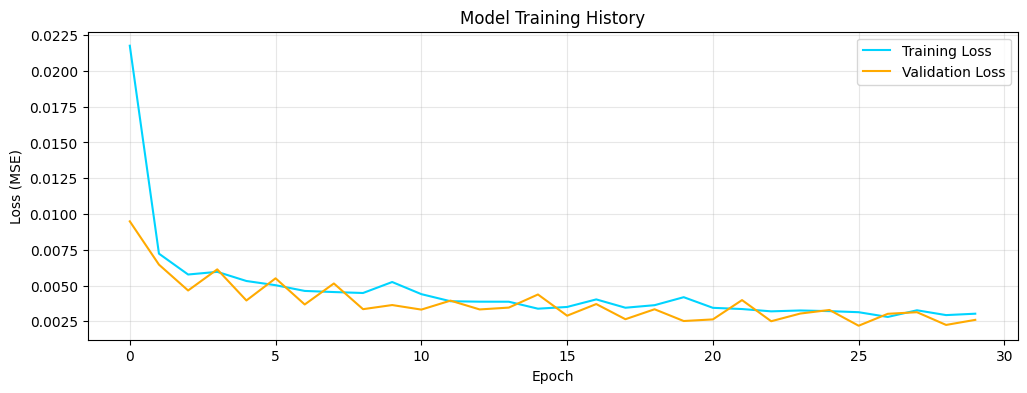

In [6]:
# ============================================
# CELL 11: Build and Train LSTM Model
# ============================================

# Build LSTM model
model = Sequential([
    LSTM(LSTM_UNITS[0], return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(DROPOUT_RATE),
    LSTM(LSTM_UNITS[1], return_sequences=False),
    Dropout(DROPOUT_RATE),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# Early stopping with validation loss
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model.summary()

# Train model
print("\n🚀 Starting training...")
history = model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ Training complete!")

# Plot training history
plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'], label='Training Loss', color='#00d4ff')
plt.plot(history.history['val_loss'], label='Validation Loss', color='#ffaa00')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Model Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Model Evaluation

### Analyst Log
I need to evaluate the model thoroughly using multiple metrics:
- **MAE** - Average error in rupees (target < ₹20)
- **RMSE** - Penalizes large errors more heavily
- **MAPE** - Percentage error (target < 3%)
- **Direction Accuracy** - % of correct up/down predictions (target > 55%)

These metrics give me a complete picture of model performance from different angles.

In [7]:
# ============================================
# CELL 13: Calculate Performance Metrics
# ============================================

# Predict on Test Set
y_pred_scaled = model.predict(X_test, verbose=0)

# Inverse transform to get actual prices
y_test_full = np.zeros((len(y_test), len(FEATURE_COLS)))
y_test_full[:, 0] = y_test
y_test_full[:, 1:] = scaled_data[split_idx + WINDOW_SIZE:split_idx + WINDOW_SIZE + len(y_test), 1:]

y_pred_full = np.zeros((len(y_pred_scaled), len(FEATURE_COLS)))
y_pred_full[:, 0] = y_pred_scaled.flatten()
y_pred_full[:, 1:] = scaled_data[split_idx + WINDOW_SIZE:split_idx + WINDOW_SIZE + len(y_pred_scaled), 1:]

y_test_actual = scaler.inverse_transform(y_test_full)[:, 0]
y_pred_actual = scaler.inverse_transform(y_pred_full)[:, 0]

# Calculate Metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

# Direction Accuracy
actual_direction = np.diff(y_test_actual) > 0
pred_direction = (y_pred_actual[1:] > y_test_actual[:-1])
direction_acc = np.mean(actual_direction == pred_direction) * 100

print("\n" + "="*60)
print("📊 TEST SET PERFORMANCE")
print("="*60)
print(f"Mean Absolute Error (MAE):      ₹{mae:.2f}")
print(f"Root Mean Square Error (RMSE):  ₹{rmse:.2f}")
print(f"Mean Absolute Percentage Error: {mape:.2f}%")
print(f"Direction Accuracy:            {direction_acc:.1f}%")
print("="*60)

# Check against targets
print("\n🎯 TARGET COMPARISON:")
print(f"MAE Target (<₹20): {'✅ PASS' if mae < 20 else '❌ FAIL'} (₹{mae:.2f})")
print(f"MAPE Target (<3%): {'✅ PASS' if mape < 3 else '❌ FAIL'} ({mape:.2f}%)")
print(f"Direction Target (>55%): {'✅ PASS' if direction_acc > 55 else '❌ FAIL'} ({direction_acc:.1f}%)")


📊 TEST SET PERFORMANCE
Mean Absolute Error (MAE):      ₹26.21
Root Mean Square Error (RMSE):  ₹34.09
Mean Absolute Percentage Error: 1.76%
Direction Accuracy:            47.0%

🎯 TARGET COMPARISON:
MAE Target (<₹20): ❌ FAIL (₹26.21)
MAPE Target (<3%): ✅ PASS (1.76%)
Direction Target (>55%): ❌ FAIL (47.0%)


In [8]:
# ============================================
# CELL 14: Visualize Predictions vs Actual
# ============================================

fig = go.Figure()

test_dates = df.index[split_idx + WINDOW_SIZE:split_idx + WINDOW_SIZE + len(y_test_actual)]

fig.add_trace(go.Scatter(
    x=test_dates, y=y_test_actual,
    name='Actual Price',
    line=dict(color='#00d4ff', width=2)
))

fig.add_trace(go.Scatter(
    x=test_dates, y=y_pred_actual,
    name='Predicted Price',
    line=dict(color='#ffaa00', width=2, dash='dot')
))

fig.update_layout(
    title='📈 Model Performance - Test Set',
    template='plotly_dark',
    xaxis_title='Date',
    yaxis_title='Price (₹)',
    height=500,
    hovermode='x unified'
)

fig.show()

## 7. Next Trading Day Prediction

### Analyst Log
Now I'll use the trained model to predict tomorrow's closing price. The model uses the last 60 days of data to make this prediction. I need to handle weekends correctly - if tomorrow is Saturday or Sunday, I'll skip to the next trading day (Monday).

In [9]:
# ============================================
# CELL 16: Generate Next Day Forecast
# ============================================

# Get Last 60 Days
last_sequence = df[FEATURE_COLS].values[-WINDOW_SIZE:]
last_scaled = scaler.transform(last_sequence)

# Reshape for LSTM
X_pred = np.reshape(last_scaled, (1, WINDOW_SIZE, len(FEATURE_COLS)))

# Predict
pred_scaled = model.predict(X_pred, verbose=0)

# Inverse transform
dummy = np.zeros((1, len(FEATURE_COLS)))
dummy[0, 0] = pred_scaled[0, 0]
dummy[0, 1:] = last_scaled[-1, 1:]  # use last known values for other features

predicted_price = scaler.inverse_transform(dummy)[0, 0]
current_price = df['Close'].iloc[-1]
next_date = df.index[-1] + timedelta(days=1)

# Skip weekends
while next_date.weekday() >= 5:  # 5 = Saturday, 6 = Sunday
    next_date += timedelta(days=1)

print("\n" + "="*60)
print("🔮 NEXT DAY PREDICTION")
print("="*60)
print(f"Current Date:     {df.index[-1].strftime('%Y-%m-%d')}")
print(f"Current Price:    ₹{current_price:.2f}")
print(f"Next Trading Day: {next_date.strftime('%Y-%m-%d')}")
print(f"Predicted Price:  ₹{predicted_price:.2f}")
print(f"Expected Change:  ₹{predicted_price - current_price:.2f} ({((predicted_price/current_price)-1)*100:+.2f}%)")
print("="*60)


🔮 NEXT DAY PREDICTION
Current Date:     2026-03-06
Current Price:    ₹1308.40
Next Trading Day: 2026-03-09
Predicted Price:  ₹1297.67
Expected Change:  ₹-10.73 (-0.82%)


## 8. Monte Carlo Simulation - Risk Quantification

### Analyst Log
To quantify risk, I'm implementing a Monte Carlo simulation using Geometric Brownian Motion (GBM). This is the standard model for stock price paths in quantitative finance.

**Key improvements I've made:**
- Using recent volatility (last 252 trading days) instead of full history
- This better reflects current market conditions
- 500 simulated paths over 30 days

**Outputs I'll track:**
- Expected price after 30 days
- 95% Value at Risk (VaR) - worst-case scenario
- Probability of loss
- Upside potential

In [10]:
# ============================================
# CELL 18: Run Monte Carlo Simulation
# ============================================

# Parameters
SIM_DAYS = 30
SIM_RUNS = 500
RECENT_WINDOW = 252

# Calculate statistics using recent data
recent_returns = df['Close'].iloc[-RECENT_WINDOW:].pct_change().dropna()
mu = recent_returns.mean()
sigma = recent_returns.std()
S0 = current_price

print(f"\n📊 Market Statistics (last {RECENT_WINDOW} days):")
print(f"   Average daily return: {mu*100:.4f}%")
print(f"   Daily volatility: {sigma*100:.4f}%")
print(f"   Annualized volatility: {sigma*np.sqrt(252)*100:.2f}%")

# Generate random shocks
np.random.seed(42)
Z = np.random.normal(0, 1, (SIM_DAYS, SIM_RUNS))

# GBM Formula
daily_returns = np.exp((mu - 0.5 * sigma**2) + sigma * Z)

# Build price paths
paths = np.zeros((SIM_DAYS + 1, SIM_RUNS))
paths[0] = S0

for t in range(1, SIM_DAYS + 1):
    paths[t] = paths[t-1] * daily_returns[t-1]

print(f"\n🎲 Simulated {SIM_RUNS} paths over {SIM_DAYS} days")

# Calculate risk metrics
final_prices = paths[-1]
expected_price = np.mean(final_prices)
median_price = np.median(final_prices)
var_95 = np.percentile(final_prices, 5)
var_99 = np.percentile(final_prices, 1)
upside_95 = np.percentile(final_prices, 95)
loss_prob = np.mean(final_prices < S0) * 100

print("\n" + "="*60)
print("📊 RISK METRICS - 30 DAY FORECAST")
print("="*60)
print(f"Expected Price:          ₹{expected_price:.2f}")
print(f"Median Price:           ₹{median_price:.2f}")
print(f"95% Value at Risk (VaR): ₹{var_95:.2f}")
print(f"99% Value at Risk (VaR): ₹{var_99:.2f}")
print(f"95% Upside Potential:    ₹{upside_95:.2f}")
print(f"Probability of Loss:     {loss_prob:.1f}%")
print("="*60)


📊 Market Statistics (last 252 days):
   Average daily return: -0.0949%
   Daily volatility: 1.6332%
   Annualized volatility: 25.93%

🎲 Simulated 500 paths over 30 days

📊 RISK METRICS - 30 DAY FORECAST
Expected Price:          ₹1272.68
Median Price:           ₹1266.45
95% Value at Risk (VaR): ₹1106.65
99% Value at Risk (VaR): ₹1053.24
95% Upside Potential:    ₹1458.84
Probability of Loss:     65.6%


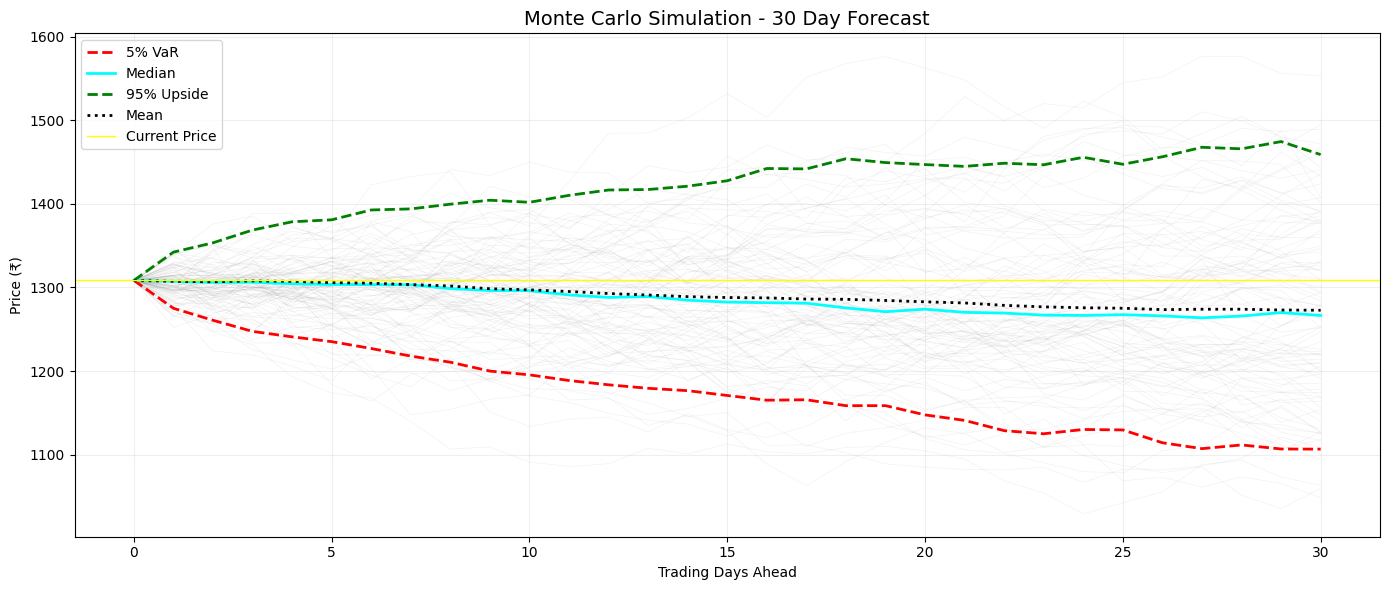

In [11]:
# ============================================
# CELL 19: Visualize Monte Carlo Simulation
# ============================================

plt.figure(figsize=(14, 6))

# Plot subset of paths
for i in range(min(100, SIM_RUNS)):
    plt.plot(paths[:, i], color='gray', alpha=0.1, linewidth=0.5)

# Plot percentiles
plt.plot(np.percentile(paths, 5, axis=1), color='red', linestyle='--', linewidth=2, label='5% VaR')
plt.plot(np.percentile(paths, 50, axis=1), color='cyan', linewidth=2, label='Median')
plt.plot(np.percentile(paths, 95, axis=1), color='green', linestyle='--', linewidth=2, label='95% Upside')
plt.plot(np.mean(paths, axis=1), color='black', linewidth=2, linestyle=':', label='Mean')

plt.axhline(y=S0, color='yellow', linestyle='-', linewidth=1, label='Current Price')

plt.title(f'Monte Carlo Simulation - {SIM_DAYS} Day Forecast', fontsize=14)
plt.xlabel('Trading Days Ahead')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 9. Save Model Artifacts

### Analyst Log
I'm saving the trained model, scaler, and configuration for later use in the Streamlit app. This ensures consistency between development and deployment.

The saved files include:
- **Model**: Keras format with weights and architecture
- **Scaler**: Pickled MinMaxScaler for feature transformation
- **Config**: Model parameters and performance metrics

In [ ]:
# ============================================
# CELL 21: Save to Disk 
# ============================================

# Create directory
os.makedirs('saved_models', exist_ok=True)

# Save model
model.save('saved_models/infy_lstm_model.keras')
print("✅ Model saved: saved_models/infy_lstm_model.keras")

# Save scaler
with open('saved_models/infy_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✅ Scaler saved: saved_models/infy_scaler.pkl")

# Get training history metrics
best_epoch = np.argmin(history.history['val_loss']) + 1
best_val_loss = min(history.history['val_loss'])

# Save config with ALL metrics
config = {
    # Model parameters
    'window_size': WINDOW_SIZE,
    'feature_cols': FEATURE_COLS,
    'lstm_units': LSTM_UNITS,
    'dropout_rate': DROPOUT_RATE,
    
    # Test metrics
    'test_mape': mape,
    'test_mae': mae,
    'test_rmse': rmse,
    'direction_accuracy': direction_acc,
    
    # Sample sizes
    'test_samples': len(y_test),
    'train_samples': len(y_train),
    
    # Training history
    'best_val_loss': best_val_loss,
    'best_epoch': best_epoch,
    'total_epochs': len(history.history['loss']),
    
    # Metadata
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

with open('saved_models/infy_config.pkl', 'wb') as f:
    pickle.dump(config, f)
print("✅ Config saved: saved_models/infy_config.pkl")

print("\n" + "="*50)
print("🎉 All model artifacts saved successfully!")
print("="*50)
print(f"📊 Model Performance Summary:")
print(f"   MAE: ₹{mae:.2f}")
print(f"   MAPE: {mape:.2f}%")
print(f"   RMSE: ₹{rmse:.2f}")
print(f"   Direction Accuracy: {direction_acc:.1f}%")
print(f"   Best Val Loss: {best_val_loss:.4f} at epoch {best_epoch}")
print("="*50)

✅ Model saved: saved_models/infy_lstm_model.keras
✅ Scaler saved: saved_models/infy_scaler.pkl
✅ Config saved: saved_models/infy_config.pkl

🎉 All model artifacts saved successfully!
📊 Model Performance Summary:
   MAE: ₹26.21
   MAPE: 1.76%
   RMSE: ₹34.09
   Direction Accuracy: 47.0%
   Best Val Loss: 0.0022 at epoch 26
